<div align="center">
<span style="color:#4B2E83;font-weight:bold;font-size:115%">W &nbsp; UNIVERSITY of WASHINGTON</span> &nbsp;·&nbsp; <span style="color:#6B6580;font-style:italic">eScience Institute</span><br>
<span style="color:#6B6580;letter-spacing:2px;font-size:90%">AI IN PRACTICE WORKSHOP</span>
</div>

# Transformers
**What you do here**

| Section | What happens | Why it matters |
|---|---|---|
| 0 | Setup | Imports, and a check for a GPU |
| 1 | The task and the data | IMDB movie reviews, and the naive baseline to beat |
| 2 | The block, in code | Write the transformer block whose diagram you saw on the slides |
| 3 | Measure the speed difference | Time an LSTM against a transformer, and read the ratio yourself |
| 4 | Score them properly | Same data, same metric, honest comparison |
| 5 | BERT | Load a pretrained model, see what it knows, and use it without fine-tuning |
| 6 | Your turn | Three experiments, starting with the one that turns a claim into a measurement |

**Frameworks.** Sections 1 to 4 use Keras, as yesterday. Section 5 uses the Hugging Face
`transformers` library with PyTorch, which is the standard tool for pretrained language models.
Colab has both installed.

**Before you start.** Set the runtime to GPU: Runtime, then Change runtime type, then Hardware
accelerator, then GPU. A GPU is not required, but section 5 is noticeably faster with one, and the
speed comparison in section 3 is far more convincing on one.

## 0. Setup

Run this first, and leave it running while the slides finish.

The GPU line matters for section 3. If it says the GPU is not available, everything still works, but
the timing comparison will understate the gap, and the reason for that is itself worth understanding:
a CPU has few cores, so there is little parallelism for the transformer to exploit.

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

# UW colours, so the plots match the slides.
UW_PURPLE, UW_GOLD, UW_TEAL, UW_PINK = "#4B2E83", "#85754D", "#1FA39B", "#C42A8B"
plt.rcParams.update({"axes.edgecolor": "#6B6580", "axes.labelcolor": "#221C35",
                     "figure.facecolor": "white", "axes.grid": True,
                     "grid.color": "#E5E0EE", "grid.linewidth": 0.8})

print("TensorFlow:", tf.__version__)
print("GPU:", "available" if tf.config.list_physical_devices("GPU") else "not available (CPU is fine)")

## 1. The task and the data

We classify IMDB movie reviews as positive or negative. The dataset ships with Keras and arrives
already tokenized as integer ids, so there is nothing to download by hand.

This task was chosen deliberately, for the reason on the slides: sentiment often turns on a
long-range relationship. In

> "the plot was predictable and the acting wooden, but I loved every minute of it"

a model that only reads local patterns sees mostly negative words. The verdict is in the final
clause, and it hinges on the word `but` several tokens earlier. That is exactly the kind of
dependency attention is supposed to handle and a short-memory model is not.

`FAST_DEMO` keeps the live session quick. Set it to `False` at home for better numbers.

**The number to beat.** The classes are balanced, so always guessing the majority class scores about
50 percent. That is the naive baseline, and it is the same habit as yesterday: if a model cannot beat
it, we say so plainly rather than quietly moving on.

In [ ]:
VOCAB, MAXLEN = 20000, 200
FAST_DEMO = True          # keeps the live session quick. Set False at home for better numbers.

(x_train, y_train), (x_val, y_val) = keras.datasets.imdb.load_data(num_words=VOCAB)

if FAST_DEMO:
    x_train, y_train = x_train[:10000], y_train[:10000]
    x_val,   y_val   = x_val[:5000],    y_val[:5000]
    EPOCHS = 3
else:
    EPOCHS = 6

x_train = keras.utils.pad_sequences(x_train, maxlen=MAXLEN)
x_val   = keras.utils.pad_sequences(x_val,   maxlen=MAXLEN)
print("train:", x_train.shape, " validation:", x_val.shape)

# The number to beat. The classes are balanced, so guessing one class gives about 50 percent.
results = {}
results["naive baseline"] = float(max(np.bincount(y_val) / len(y_val)))
print(f"\nNaive baseline accuracy: {results['naive baseline']:.3f}  (always guess the majority class)")

## 2. The block, in code

The slides ended on the diagram of a transformer encoder block. Here it is written out, in two small
classes.

**`TokenAndPositionEmbedding`** does two lookups and adds them: one for what the token is, one for
where it sits. The position lookup is needed because attention is order-blind, a weighted average has
no sense of sequence, so position has to be supplied separately. The `use_positions` switch lets you
turn it off in section 6 and measure what it was worth.

**`TransformerBlock`** is four steps: multi-head self-attention (every token reads every token), add
and normalize, a feed-forward layer, add and normalize again. The output has the same shape as the
input, which is why blocks can stack.

In [ ]:
class TokenAndPositionEmbedding(layers.Layer):
    """Two lookups added together: what the token is, and where it sits."""
    def __init__(self, maxlen, vocab_size, embed_dim, use_positions=True, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb   = layers.Embedding(maxlen, embed_dim)
        self.use_positions = use_positions

    def call(self, x):
        tokens = self.token_emb(x)
        if not self.use_positions:
            return tokens                        # order-blind, for the ablation later
        positions = tf.range(tf.shape(x)[-1])
        # TODO 1: add the position embedding to the token embedding.
        return ...


class TransformerBlock(layers.Layer):
    """Self-attention, then a feed-forward network, each wrapped in add-and-normalize."""
    def __init__(self, embed_dim, num_heads, ff_dim, **kwargs):
        super().__init__(**kwargs)
        self.att   = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn   = keras.Sequential([layers.Dense(ff_dim, activation="relu"),
                                       layers.Dense(embed_dim)])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

    def call(self, inputs):
        # TODO 2: self-attention. Every token reads every token, so the query and the
        #         key/value source are BOTH `inputs`.
        attn = ...
        # TODO 3: add the input back (residual), then normalize.
        x    = ...
        ffn  = self.ffn(x)
        # TODO 4: the second residual, around the feed-forward network, then normalize.
        return ...

print("Layers defined.")

**Stuck on a line?** Fill in each `...` yourself first. Open a hint only if you need it.

<details>
<summary>Hint for TODO 1</summary>
<pre>return tokens + self.pos_emb(positions)</pre>
</details>

<details>
<summary>Hint for TODO 2</summary>
<pre>attn = self.att(inputs, inputs)</pre>
</details>

<details>
<summary>Hint for TODO 3</summary>
<pre>x = self.norm1(inputs + attn)</pre>
</details>

<details>
<summary>Hint for TODO 4</summary>
<pre>return self.norm2(x + ffn)</pre>
</details>

In [ ]:
EMBED_DIM, NUM_HEADS, FF_DIM = 32, 2, 32

def build_transformer(use_positions=True, num_heads=NUM_HEADS, num_blocks=1):
    inputs = keras.Input(shape=(MAXLEN,))
    x = TokenAndPositionEmbedding(MAXLEN, VOCAB, EMBED_DIM, use_positions=use_positions)(inputs)
    for _ in range(num_blocks):
        x = TransformerBlock(EMBED_DIM, num_heads, FF_DIM)(x)
    x = layers.GlobalAveragePooling1D()(x)       # one vector per review
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(20, activation="relu")(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    return keras.Model(inputs, outputs)

def build_lstm():
    return keras.Sequential([
        keras.Input(shape=(MAXLEN,)),
        layers.Embedding(VOCAB, EMBED_DIM),
        layers.Bidirectional(layers.LSTM(32)),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ])

print("transformer parameters:", build_transformer().count_params())
print("LSTM parameters:       ", build_lstm().count_params())

## 3. Measure the speed difference

An RNN cannot keep a GPU busy, because step five waits for step four, while a transformer computes
every position in one matrix multiplication. That is a claim about hardware, so measure it. Same
data, same batch size, one epoch each.

On a GPU the gap should be clear. On a CPU it will be much smaller, because a CPU has few cores and so
little parallelism to exploit, and that is worth saying out loud when you read your number.

In [ ]:
def time_one_epoch(model, name):
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    model.fit(x_train, y_train, batch_size=64, epochs=1, verbose=0)
    dt = time.time() - t0
    print(f"{name:<28} {dt:6.1f} seconds for one epoch")
    return dt

t_lstm = time_one_epoch(build_lstm(),        "LSTM (sequential)")
t_trf  = time_one_epoch(build_transformer(), "Transformer (parallel)")

print(f"\nThe transformer was {t_lstm / t_trf:.1f}x faster per epoch on this hardware.")
print("Scale that up to billions of tokens and it is the difference between possible and impossible.")

## 4. Score them properly

Speed is only half the story. Train both on the same data and compare their accuracy against the
naive baseline, the same honest habit as yesterday.

In [ ]:
def train_and_score(model, name, epochs=None):
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.fit(x_train, y_train, validation_data=(x_val, y_val),
              batch_size=64, epochs=epochs or EPOCHS, verbose=0)
    acc = float(model.evaluate(x_val, y_val, verbose=0)[1])
    results[name] = acc
    verdict = "beats" if acc > results["naive baseline"] else "does not beat"
    print(f"{name:<24} accuracy {acc:.3f}   ({verdict} the naive baseline)")
    return acc

train_and_score(build_lstm(),        "LSTM")
train_and_score(build_transformer(), "Transformer")

**Read this honestly.** On a task this small the transformer and the LSTM land close together, and
neither crushes the other. The transformer did not win on accuracy here, and at this size it should
not be expected to.

What it won was the speed test in section 3. Training in parallel is what makes it affordable to
pretrain one very large model on an enormous amount of text, once, and then reuse it everywhere. That
reused model is BERT, and section 5 is where we meet it.

## 5. BERT

BERT is a stack of the transformer encoder blocks you just built, and nothing else. Google trained it
once on a large corpus of books and Wikipedia, and released the weights. You are about to download
that result and use it.

<div align="center">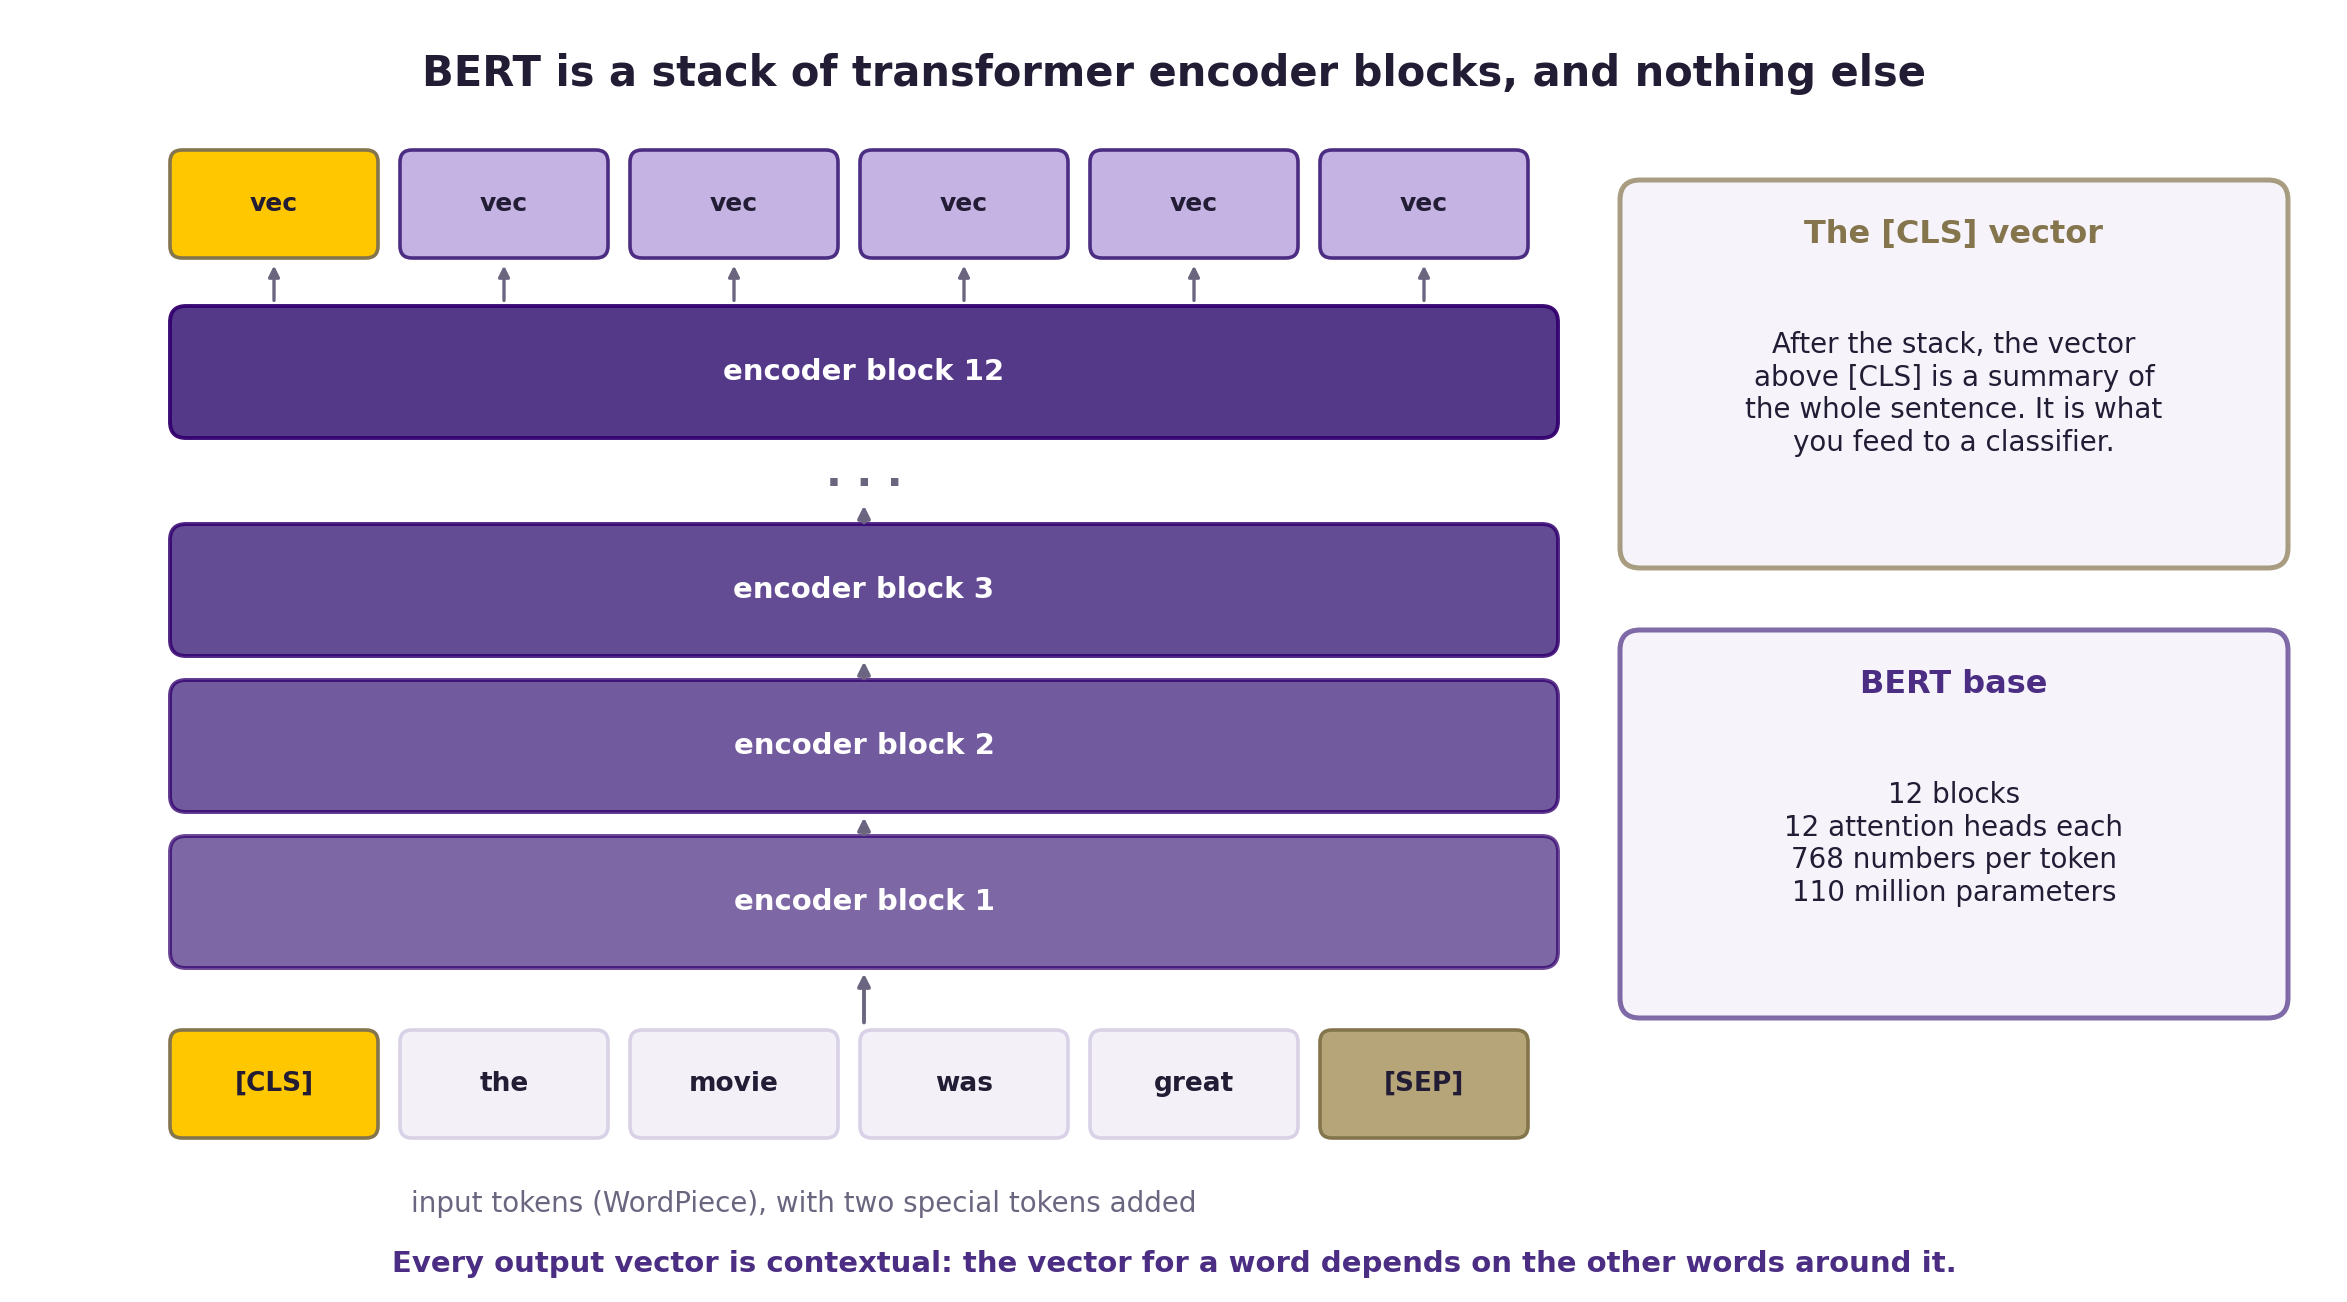</div>

The name describes the design. It is **B**idirectional (it reads left and right at once), an
**E**ncoder (it turns text into vectors, it does not generate text), and it produces
**R**epresentations from **T**ransformers (one contextual vector per token, which you attach your own
task to). BERT base has 12 encoder blocks, 12 attention heads each, 768 numbers per token, and about
110 million parameters.

### How BERT was pretrained

Hide about 15 percent of the tokens in a sentence at random, and train the model to guess them. No
human labels anything, so every sentence ever written is a free training example. To guess a hidden
word well, the model has to pick up grammar, word meaning, and facts about the world.

<div align="center">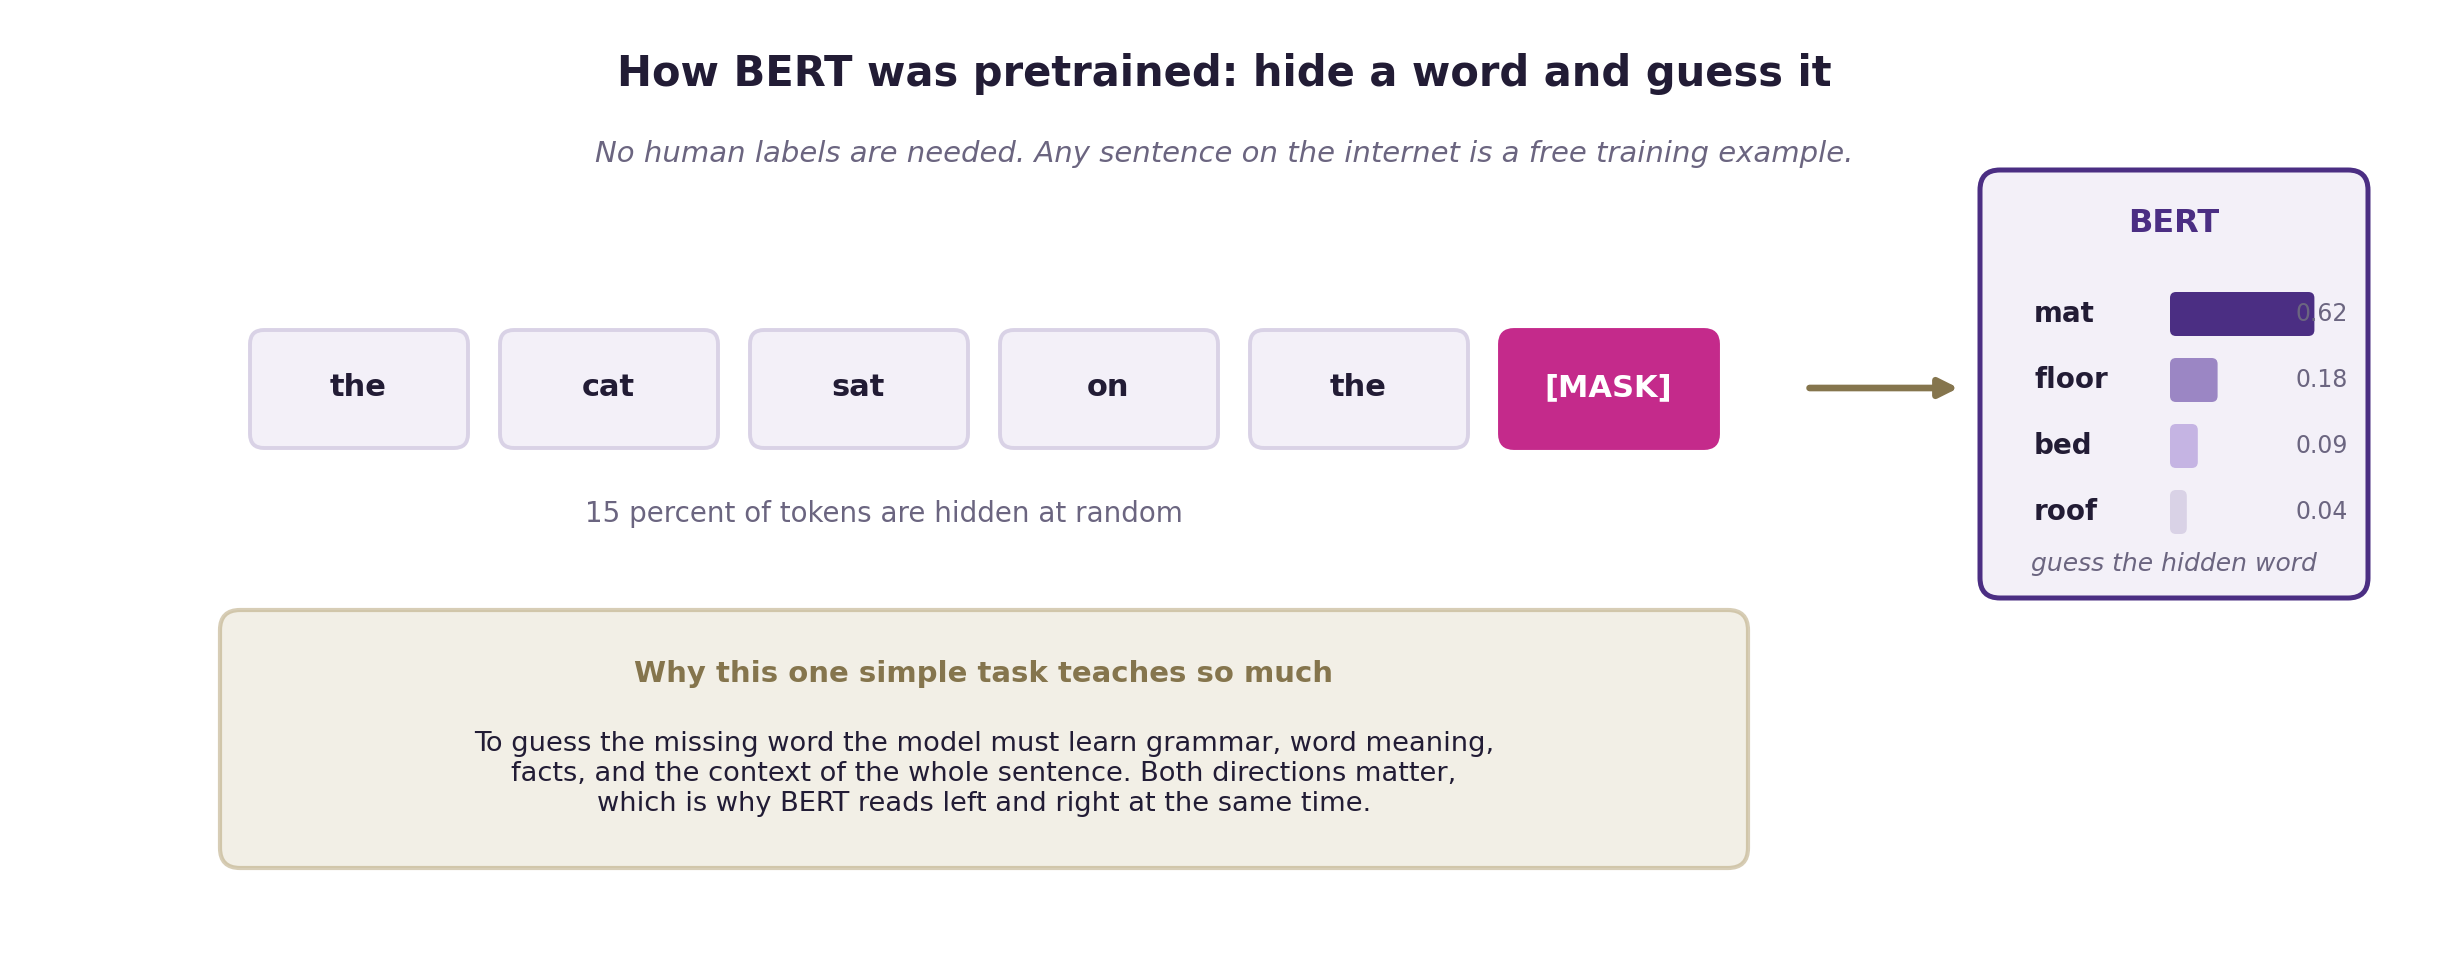</div>

Because it is filling in a blank rather than generating the next word, it is allowed to read both
sides of the gap at once. That is the bidirectional idea from yesterday, now at scale.

<div align="center">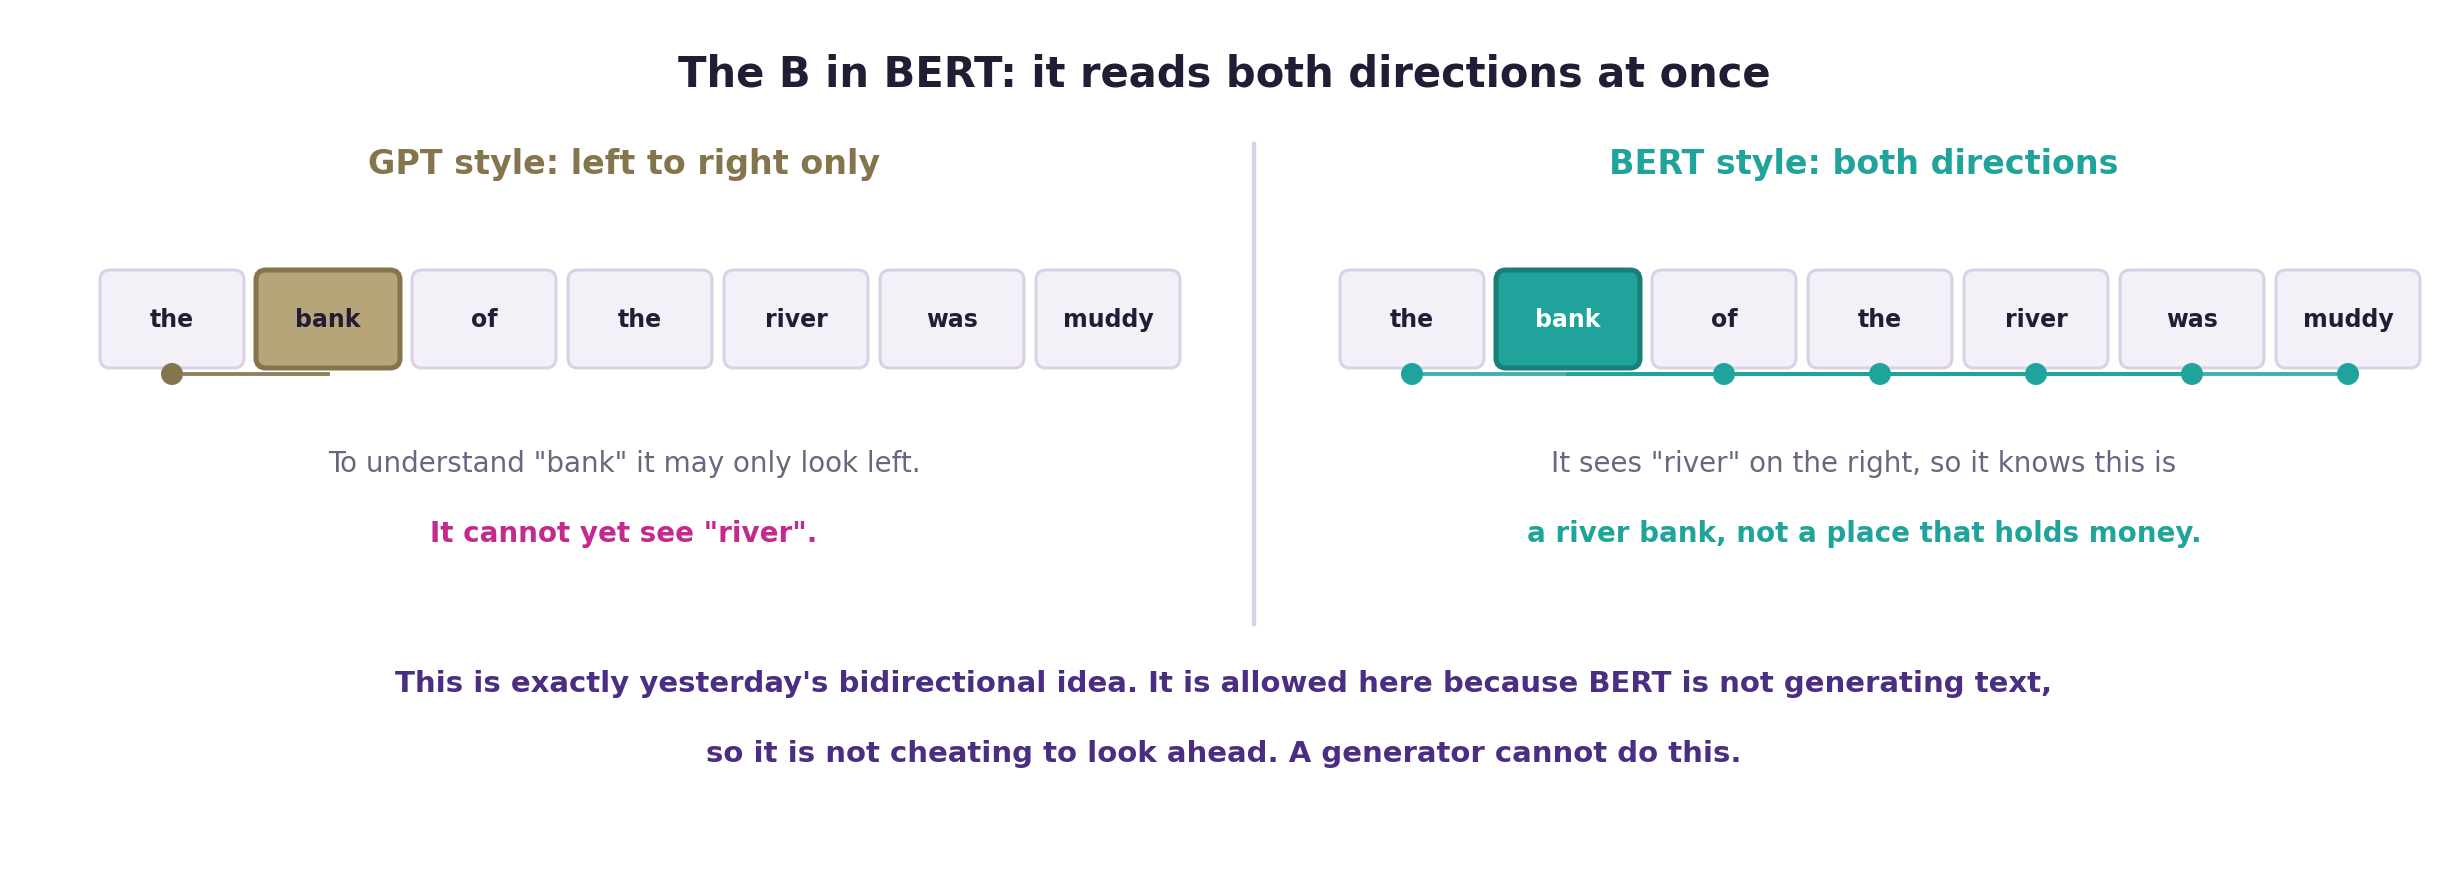</div>

### Loading a pretrained BERT

The Hugging Face `transformers` library is three objects: a tokenizer, a model, and its outputs. The
same few lines load any of thousands of pretrained models, including ones trained on biomedical text,
code, or protein sequences.

<div align="center">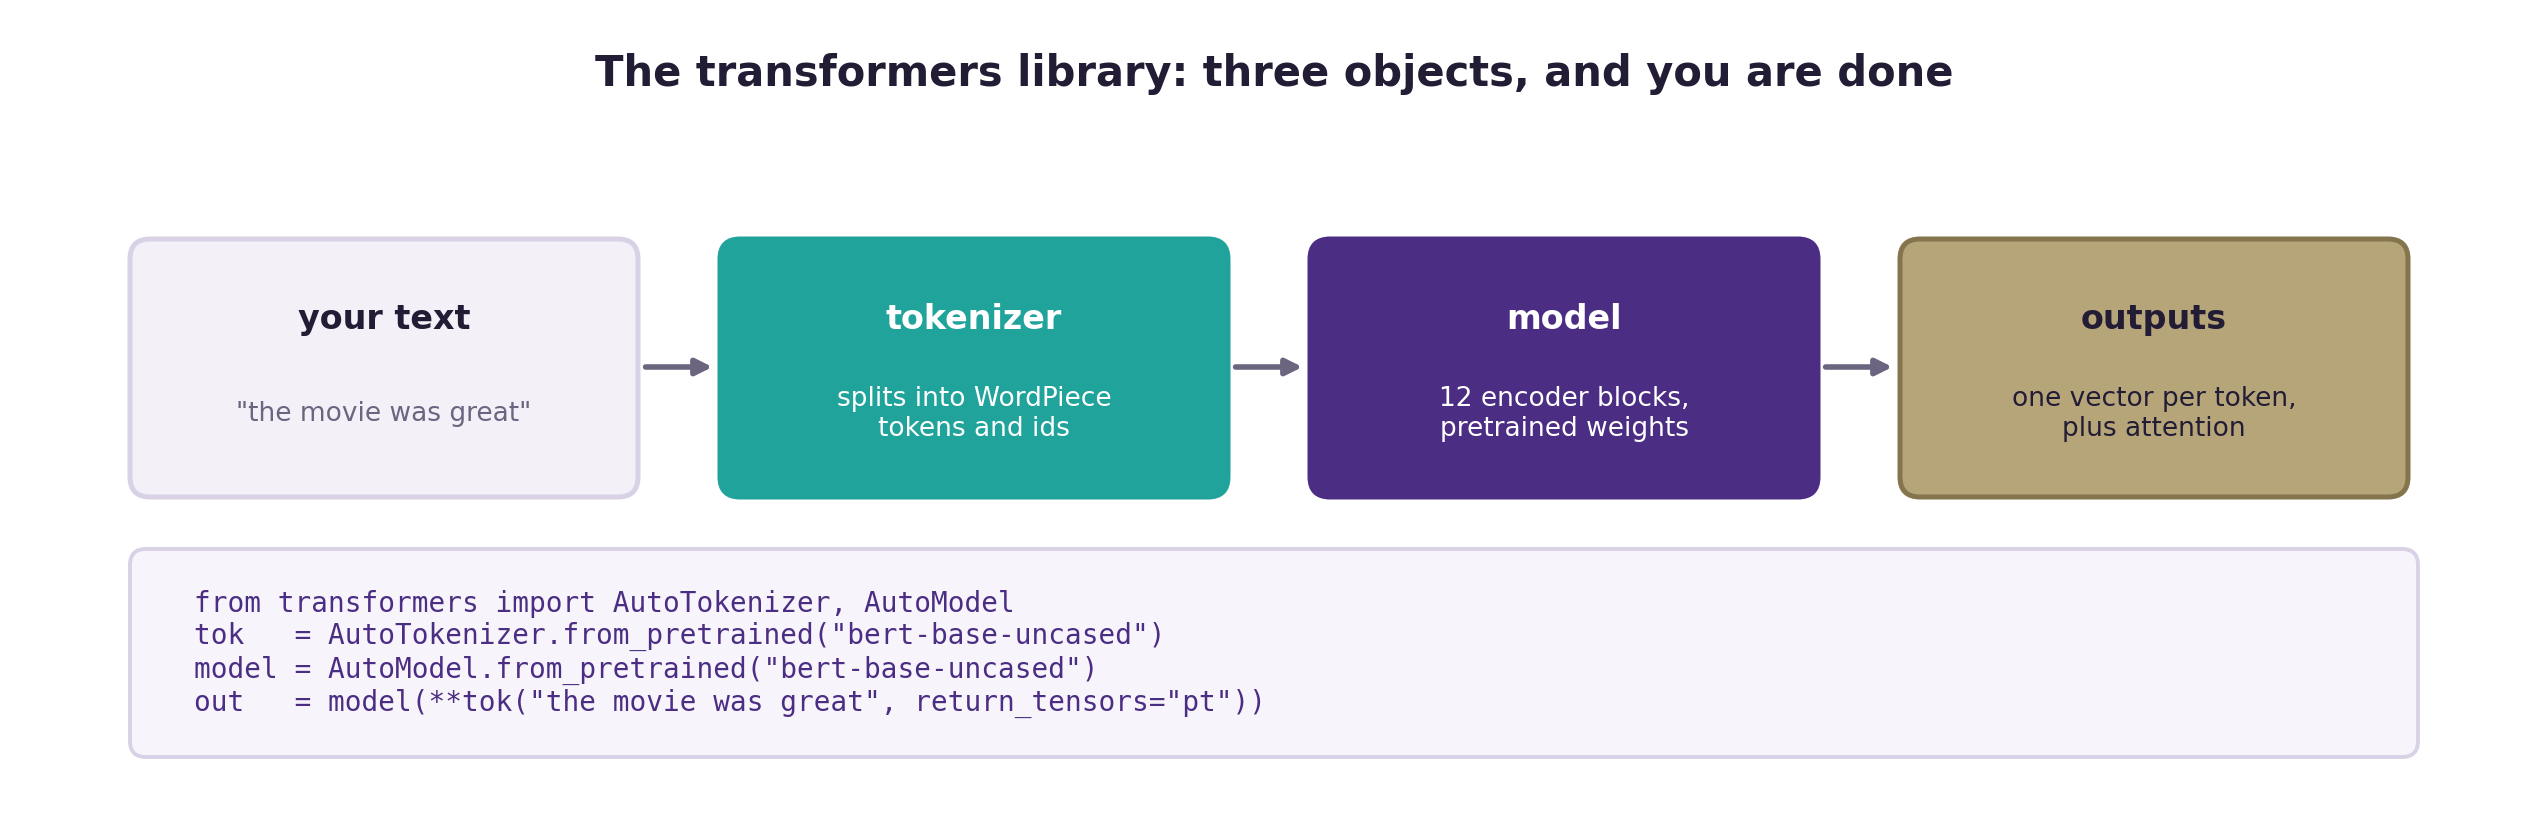</div>

**Code 5a.** Download and load BERT. The weights are about 440 MB and cache after the first run.

In [ ]:
# Colab already includes transformers. Uncomment if you are running elsewhere.
# !pip install -q transformers

import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForMaskedLM

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert = AutoModel.from_pretrained(MODEL_NAME)
bert.eval()          # inference mode: we are not training it

print(f"Loaded {MODEL_NAME}: {sum(p.numel() for p in bert.parameters()):,} parameters, "
      f"{bert.config.num_hidden_layers} blocks, {bert.config.num_attention_heads} heads/block")

### Its word vectors are contextual

BERT is not a fixed dictionary of word vectors. The same word gets a different vector depending on the
sentence around it. The clearest test is the word `bank`: it should look one way among rivers and
another way among cheques. Cosine similarity is 1.0 for identical direction and near 0 for unrelated.

**Code 5b.**

In [ ]:
def bank_vector(sentence):
    """BERT's contextual vector for the word 'bank' in this sentence."""
    enc  = tokenizer(sentence, return_tensors="pt")
    toks = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    with torch.no_grad():
        h = bert(**enc).last_hidden_state[0]
    return h[toks.index("bank")]

def cosine(a, b):
    return float(torch.dot(a, b) / (a.norm() * b.norm()))

river  = bank_vector("I sat on the bank of the river and watched the water.")
stream = bank_vector("We walked along the grassy bank beside the stream.")
money  = bank_vector("I deposited the cheque at the bank on Tuesday.")

print(f"river-bank vs river-bank : {cosine(river, stream):.2f}   (same sense, high)")
print(f"river-bank vs money-bank : {cosine(river, money):.2f}   (different sense, lower)")

### Does it already know things?

Run the exact task BERT was pretrained on: fill in the blank. `AutoModelForMaskedLM` is BERT with its
original word-guessing head still attached.

**Code 5c.**

In [ ]:
mlm = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)
mlm.eval()

def fill_blank(text, top_k=5):
    """text must contain [MASK] exactly once."""
    enc = tokenizer(text, return_tensors="pt")
    idx = (enc["input_ids"][0] == tokenizer.mask_token_id).nonzero().item()
    with torch.no_grad():
        probs = mlm(**enc).logits[0, idx].softmax(-1)
    print(f"\n{text}")
    for p, tid in zip(*probs.topk(top_k)):
        print(f"   {tokenizer.decode([tid]).strip():<12} {float(p):.2f}")

fill_blank("The capital of France is [MASK].")
fill_blank("Water boils at one hundred [MASK].")
fill_blank("The patient was given an [MASK] to treat the infection.")

**Sit with that.** Nobody taught BERT geography or medicine. It learned it all by guessing hidden
words, and that knowledge now sits in its weights, free to reuse. The same process also absorbed the
biases in its training text, which exercise B looks at and Friday's session takes up.

### Using BERT without fine-tuning

There are two ways to put a pretrained BERT to work.

<div align="center">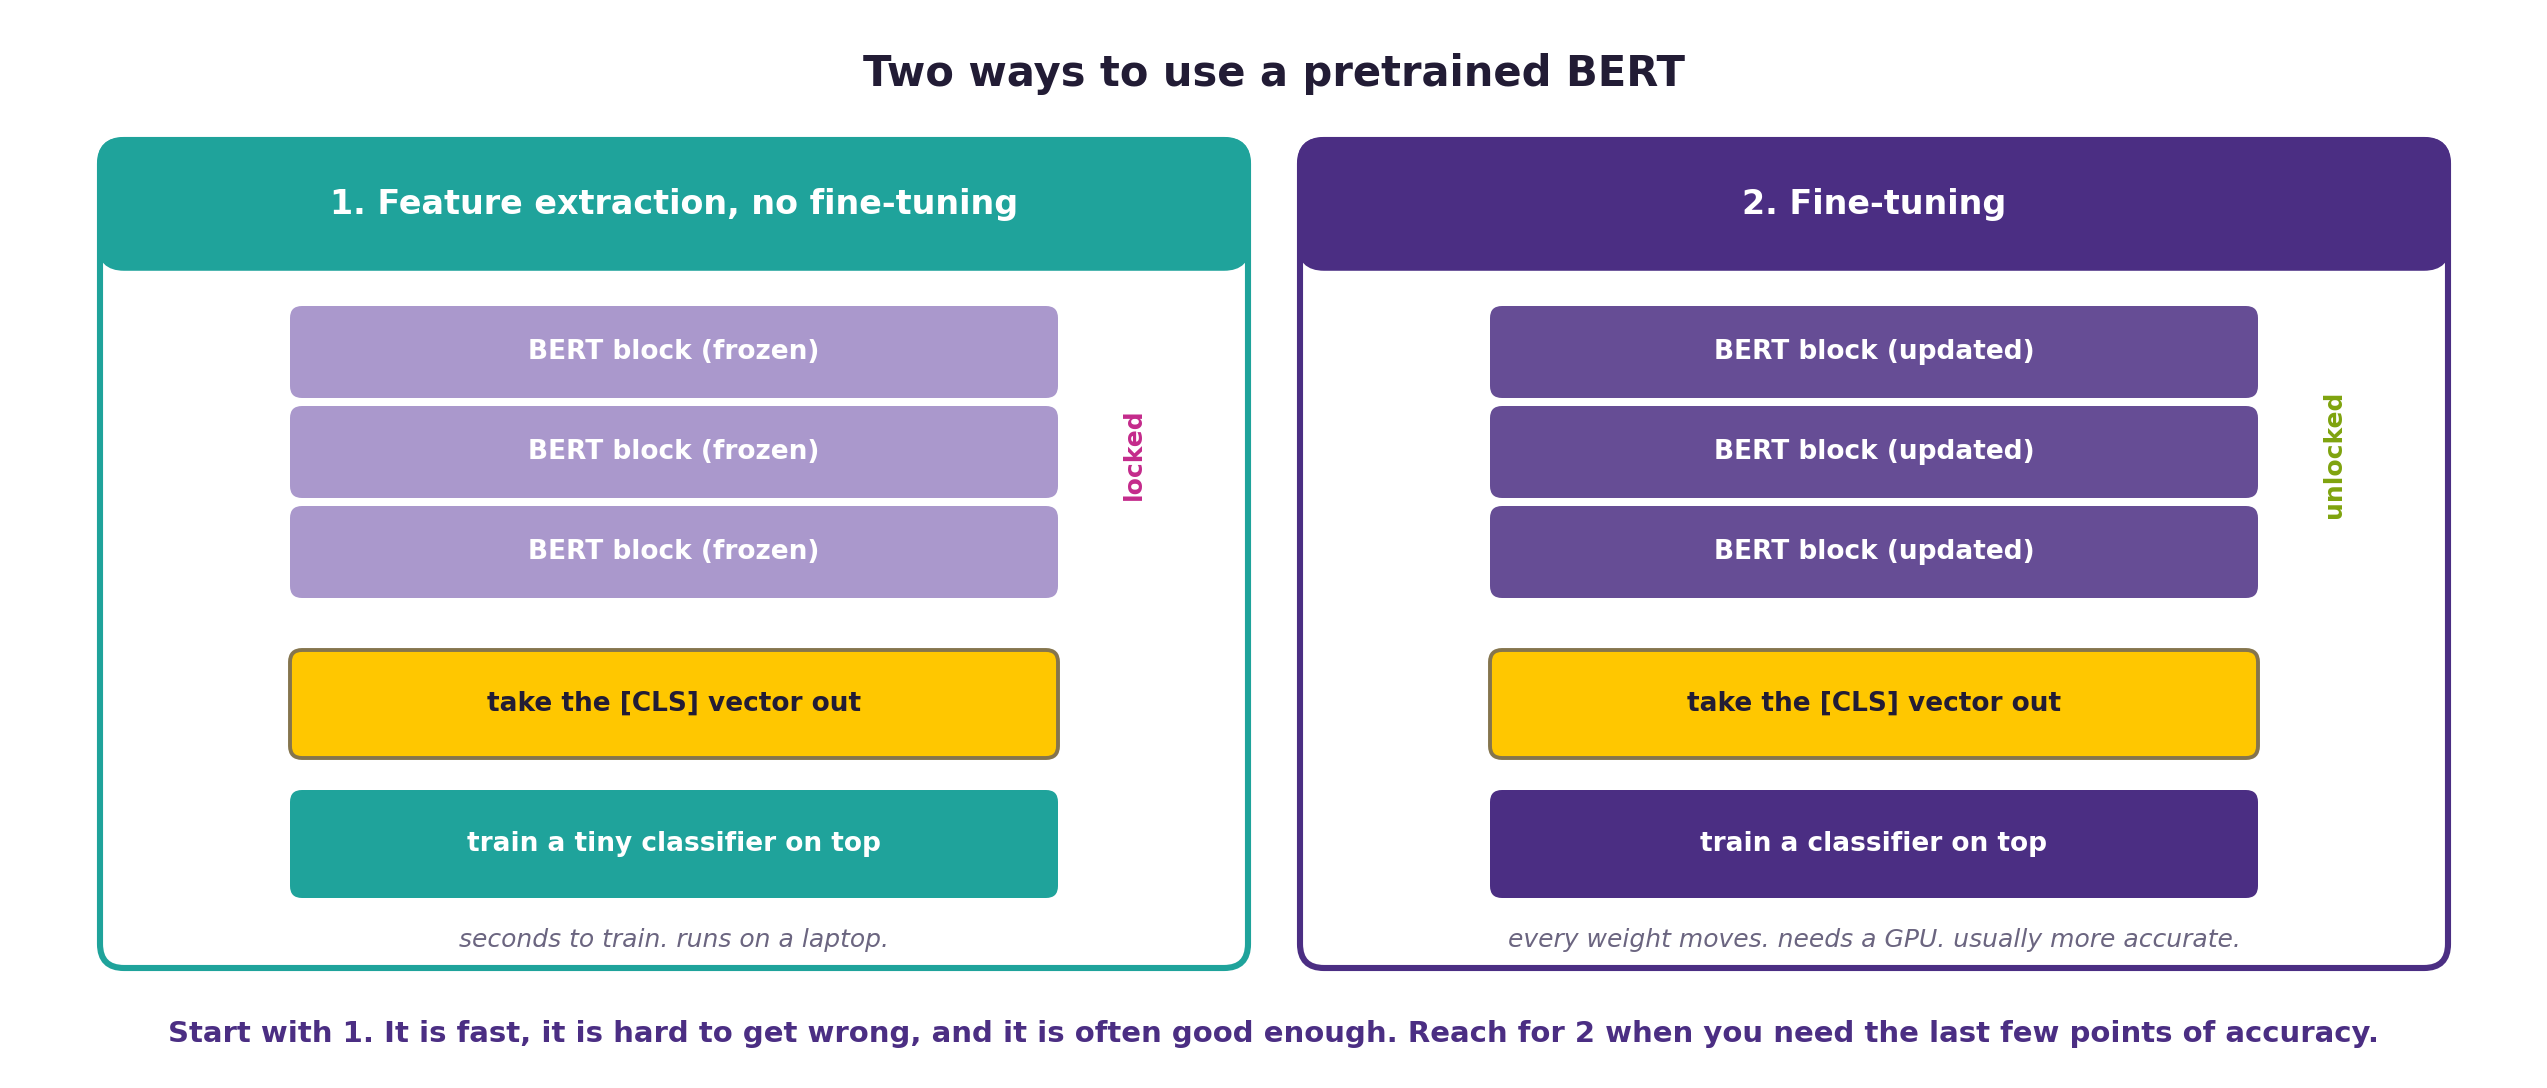</div>

**Feature extraction** freezes BERT, pushes your text through it, and trains a small ordinary
classifier on the vectors that come out. BERT never changes; you are using it as a well-informed
text-to-vector function. It trains in seconds. **Fine-tuning** instead lets all 110 million weights
adjust to your task: usually more accurate, but it needs a GPU and is easier to get wrong.

We do feature extraction below: freeze BERT, take the `[CLS]` vector of each review, and fit a
logistic regression on top.

**Code 5d.**

In [ ]:
from sklearn.linear_model import LogisticRegression

# BERT reads text, but IMDB arrives as integer ids, so rebuild the words first.
id_to_word = {v + 3: k for k, v in keras.datasets.imdb.get_word_index().items()}
def to_text(ids, max_words=120):
    return " ".join(id_to_word[i] for i in ids if i > 2 and i in id_to_word)[:600]

device = "cuda" if torch.cuda.is_available() else "cpu"
bert.to(device)

def cls_features(texts):
    """Frozen BERT: the [CLS] vector (768 numbers) for each text."""
    out = []
    for i in range(0, len(texts), 32):
        batch = tokenizer(texts[i:i + 32], padding=True, truncation=True,
                          max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            out.append(bert(**batch).last_hidden_state[:, 0].cpu().numpy())
    return np.vstack(out)

N_TRAIN, N_TEST = 1500, 600
print(f"Encoding {N_TRAIN + N_TEST} reviews with frozen BERT on {device} (the slow step)...")
Xtr = cls_features([to_text(r) for r in x_train[:N_TRAIN]])
Xte = cls_features([to_text(r) for r in x_val[:N_TEST]])

clf = LogisticRegression(max_iter=2000).fit(Xtr, y_train[:N_TRAIN])
results["BERT (frozen)"] = float(clf.score(Xte, y_val[:N_TEST]))
print(f"BERT frozen [CLS] + logistic regression: {results['BERT (frozen)']:.3f}")

**Code 5e.** Put everything on one chart.

In [ ]:
names  = list(results.keys())
vals   = [results[k] for k in names]
colors = [UW_PINK if k == "naive baseline" else (UW_TEAL if k.startswith("BERT") else UW_PURPLE)
          for k in names]

plt.figure(figsize=(10, 4.2))
bars = plt.barh(names, vals, color=colors)
plt.axvline(results["naive baseline"], color=UW_PINK, ls="--", lw=1.5)
for b, v in zip(bars, vals):
    plt.text(v + 0.005, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontsize=10)
plt.xlim(0.4, 1.0)
plt.xlabel("Validation accuracy")
plt.title("Everything we built today, on the same task", fontweight="bold")
plt.tight_layout(); plt.show()

print("The teal bar had no training on this task at all.")

**Read the chart honestly.** Frozen BERT lands a little *below* the transformer and the LSTM you
trained. That is not a bug, and it is worth understanding rather than hiding.

We used the raw `[CLS]` vector as each review's feature. But `[CLS]` only *learns* to summarize a whole
input while a model is fine-tuned on a sentence-level task, and we did no fine-tuning, so here it is a
fairly weak summary. Two things recover the gap: averaging all of BERT's token vectors instead of
using `[CLS]` (that is exercise C, and it lands right around the LSTM), and fine-tuning, where the
weights actually adapt and BERT pulls clearly ahead.

So the honest takeaway is not that BERT beats everything out of the box. It is that a model pretrained
on a huge corpus gives you a strong result in seconds, with no task-specific training and a one-line
classifier on top. That is an excellent place to start, and fine-tuning is the next step when you need
the last few points. Fine-tuning uses `AutoModelForSequenceClassification` and a normal training loop;
it typically adds a few points of accuracy, needs a GPU, and takes minutes rather than seconds.

---
# Your turn

Three experiments. Do A first. B is worth doing as a room.

### A. What is word order worth?

The slides showed that attention is order-blind by construction, because a weighted average has no notion of order. Now measure what that costs on real data, by rebuilding
*your* transformer with the positional embedding switched off.

In [ ]:
# TODO 5: build the same transformer with positions switched off, then score it.
#          build_transformer() already takes a use_positions argument.
no_pos = ...
train_and_score(no_pos, "Transformer, no positions")

drop = results["Transformer"] - results["Transformer, no positions"]
print(f"\nAccuracy change from removing word order: {drop:+.3f}")
print("Close to zero here: sentiment is largely a bag of words, so order barely helps.")

<details>
<summary>Hint for TODO 5</summary>
<pre>no_pos = build_transformer(use_positions=False)</pre>
</details>

### B. Probe what BERT absorbed

BERT learned from a very large amount of human text, and it absorbed the patterns in that text,
including ones nobody intended to teach it.

Run the two below, then write your own. Try professions, nationalities, gendered pronouns. Look at what
comes back and note what you find. Friday's session is about exactly this.

In [ ]:
fill_blank("The nurse said that [MASK] would be back shortly.")
fill_blank("The engineer said that [MASK] would be back shortly.")

# Now write two of your own.
# fill_blank("... [MASK] ...")

### C. Does averaging beat the [CLS] vector?

In Code 5d we turned each review into one vector by taking the **`[CLS]` token's** output
(`last_hidden_state[:, 0]`, the first token) and trained logistic regression on it. It scored a little
below the LSTM and the transformer.

BERT actually outputs one vector *per token*, so there is a second way to get a single review vector:
instead of using only `[CLS]`, **average the vectors of every token** (`last_hidden_state.mean(1)`).
This "mean pooling" blends the whole review together, and for a frozen BERT that was never fine-tuned
it is usually the better summary, the one the honest note above said would close most of the gap.

Try it: copy `cls_features` into a new `mean_features` that averages instead of taking `[CLS]`,
re-encode the reviews, re-fit the logistic regression, and compare the accuracy.

<details>
<summary>Hint: the full solution</summary>
<pre>
def mean_features(texts):
    out = []
    for i in range(0, len(texts), 32):
        batch = tokenizer(texts[i:i + 32], padding=True, truncation=True,
                          max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            out.append(bert(**batch).last_hidden_state.mean(1).cpu().numpy())
    return np.vstack(out)

Xtr = mean_features([to_text(r) for r in x_train[:N_TRAIN]])
Xte = mean_features([to_text(r) for r in x_val[:N_TEST]])
clf = LogisticRegression(max_iter=2000).fit(Xtr, y_train[:N_TRAIN])
print("BERT frozen (mean pooling) + logreg:", round(clf.score(Xte, y_val[:N_TEST]), 3))
</pre>
</details>

In [ ]:
# Your experiment here.

---

# Takeaways

- A transformer replaces recurrence with attention, so it computes every position at once. You timed
  it against an LSTM: the win is **speed**, not a higher score on a small task.
- That speed is what makes it affordable to **pretrain** one large model on an enormous corpus. BERT
  is a stack of encoder blocks pretrained by guessing hidden words, with no human labels.
- A pretrained BERT gives strong results with almost no work: freeze it, take a vector, fit a small
  classifier. Frozen `[CLS]` is only a rough summary without fine-tuning, so it will not always beat a
  model you trained, but it gets you most of the way in seconds. Fine-tuning closes the rest.

**The practical lesson.** Before designing an architecture, try a pretrained model with a small
classifier on top. It takes minutes and is often good enough, and it is the honest baseline any
fancier approach has to beat.

### What is next

The architecture stops changing here. What changes is scale: more parameters, more data, more
compute. That is tomorrow.

---

### Sources and credits

- Luis Serrano, "The math behind Attention: Keys, Queries and Values matrices", Serrano.Academy:
  https://www.youtube.com/watch?v=UPtG_38Oq8o
- Bahdanau, Cho and Bengio, "Neural Machine Translation by Jointly Learning to Align and Translate",
  ICLR 2015: https://arxiv.org/abs/1409.0473
- Vaswani et al., "Attention Is All You Need", 2017: https://arxiv.org/abs/1706.03762
- Devlin et al., "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding",
  2018: https://arxiv.org/abs/1810.04805
- Hugging Face transformers documentation: https://huggingface.co/docs/transformers

All diagrams were made for this workshop.

<div align="center" style="color:#4B2E83"><strong>University of Washington &middot; eScience Institute</strong></div>